<a href="https://colab.research.google.com/github/deepthii1316/ML-from-scratch/blob/main/ML_External_Files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DBSCAN clustering algo



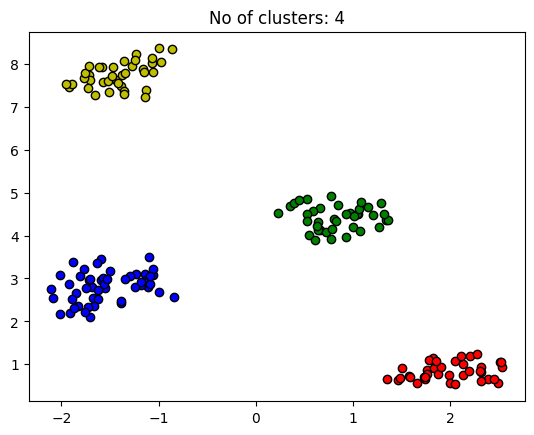

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

X, y_true = make_blobs(
    n_samples = 300,
    centers = 4,
    cluster_std = 0.5,
    random_state = 0
)

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_,dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)


colors = ['y','b','g','r']
for k,col in zip(unique_labels,colors):
  if k==-1:
    col = 'k'
  #pick memebrs of that cluster
  class_member_mask = (labels == k)
  xy = X[class_member_mask & core_samples_mask]
  plt.plot(xy[:,0],xy[:,1],'o',
           markerfacecolor=col,
           markeredgecolor='k',
           markersize=6
           )

  xy = X[class_member_mask & ~core_samples_mask]
  plt.plot(xy[:,0],xy[:,1],'o',
           markerfacecolor=col,
           markeredgecolor='k',
           markersize=6
           )

plt.title("No of clusters: "+ str(n_clusters_))
plt.show()



## K Nearest Neighbors Classification

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
data = load_breast_cancer()
X, y = data.data, data.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=43)
knn = KNeighborsClassifier(n_neighbors=3)


knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

print("Actual values:",y_test[:10])
print("Predic values:",y_pred[:10])

print("Accuracy score",accuracy_score(y_test,y_pred))

Actual values: [1 1 0 0 0 1 1 1 0 0]
Predic values: [0 1 0 0 0 0 1 1 0 0]
Accuracy score 0.9298245614035088


## Naive Bayes Classifier

In [30]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report,accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.3,
                                                 random_state=42
                                                 )
nb = GaussianNB()
nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)

print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Classification Report")
print(classification_report(y_test,y_pred,target_names=data.target_names))


#Testing
new_ip = X_test[0].reshape(1,-1)
new_pred = nb.predict(new_ip)
print("Diagnosis: ",data.target_names[new_pred[0]])

Accuracy score:  0.9415204678362573
Classification Report
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        63
      benign       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171

Diagnosis:  benign


## Logistic Regression

Accuracy:  0.9824561403508771
Classification report:
              precision    recall  f1-score   support

   malignant       0.97      0.98      0.98        63
      benign       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

Diagnosis:  malignant


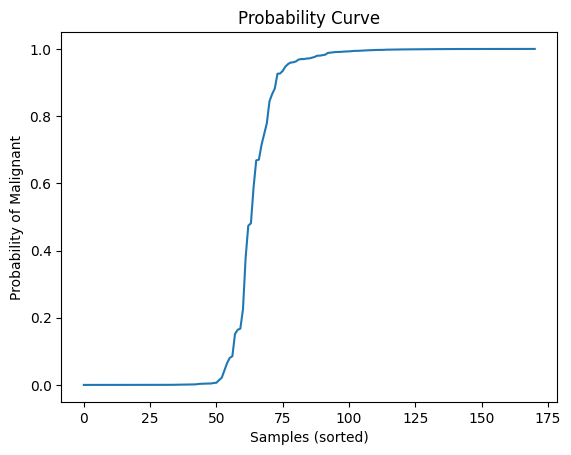

In [54]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
m = LogisticRegression(max_iter = 1000)
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)

m.fit(X_train,y_train)
y_pred = m.predict(X_test)

print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification report:")
print(classification_report(y_test,y_pred,target_names=data.target_names))

new_inp = X_test[1].reshape(1,-1)
new_pred = m.predict(new_inp)
print("Diagnosis: ",data.target_names[new_pred[0]])

probs = m.predict_proba(X_test)
sorted_probs = np.sort(probs[:, 1])

plt.plot(sorted_probs)
plt.xlabel("Samples (sorted)")
plt.ylabel("Probability of Malignant")
plt.title("Probability Curve")
plt.show()

## Bagging

In [51]:
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score

data = load_wine()
X,y=data.data,data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=23)
model = BaggingClassifier(
    random_state=23,
    bootstrap=True,
    oob_score=True,
    n_estimators=16
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("Accuracy score:",accuracy_score(y_test,y_pred))
print("OOB Score:",model.oob_score_)

Accuracy score: 1.0
OOB Score: 0.9193548387096774


## Boosting

In [52]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score

data = load_wine()
X,y=data.data,data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=23)
model = GradientBoostingClassifier(
    random_state=23,
    learning_rate=0.05,
    max_features=5,
    n_estimators=300
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("Accuracy score:",accuracy_score(y_test,y_pred))


Accuracy score: 1.0


## Logistic Regression (Record)

In [ ]:
from sklearn.